# Dependecies Installation

---

In [ ]:
!pip install eodag rasterio opencv-python tifffile numpy segmentation-models-pytorch mapclassify pyngrok flask

# Variables Definition

---



In [ ]:
from datetime import datetime, timedelta
import torch

#Path to read shape file, the parent folder should contain all related aditional files to .shp, ex. .prj, .dbf, .cpg
path_shp = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/reference_cages/reference_cages.shp"

#Folder to write the CSV files with coordinates and their relation to polygons
path_shp_out = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/reference_cages_out/"

#Folder to download images
download_folder = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_rgb"

#Folder to store 'npy' converted images
output_folder = '/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy'

# Credentials to connect with API for getting images
client_id = "sh-xxxxxxxxxxxxxxxxxxxxxx"
client_secret = "xxxxxxxxxxxxxxxxxxxxxxxxx"
token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"

# Rank of dates when to get the images (YYYY, MM, D)
start_date = "2024-01-01T00:00:00Z"
end_date = "2024-12-30T00:00:00Z"

# =====MODEL INFERENCE CONFIG =====
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_MEAN_3_CHANNEL = (0.485, 0.456, 0.406)
IMG_STD_3_CHANNEL  = (0.229, 0.224, 0.225)
PATCH_SIZE = 512
MIN_AREA = 50  # Minimum area for predicted polygons, used to filter out predicted polygons that have an area smaller than this value, likely removing noise or very small predictions that are not of interest

IMAGE_DIR = output_folder  # folder containing sentinel2_{cluster_id}.npy
CLUSTER_CSV = path_shp_out + "clustered_centroids.csv"
MAPPING_CSV = path_shp_out + "polygon_cluster_mapping.csv"
REFERENCE_SHP = path_shp
OUTPUT_SHP = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/result/predicted_polygons_with_metrics.shp"
MODEL_PATH = "/content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/best_model_rgb.pth"

* In order to get credentials for the copernicus dataspace API, it is necesary to create an account in: https://dataspace.copernicus.eu/.

* Aditionally, there should be created the OAuth client. More info in: https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/UserGuides/BeginnersGuide.html#curl-cli-and-python

# Images Preparation

---



## Getting coordinates from Shapefiles

---



In [ ]:
import geopandas as gpd
from sklearn.cluster import DBSCAN
import numpy as np
import csv
import hashlib

# Function to hash geometry WKT
def geometry_hash(geom):
    wkt = geom.wkt
    return hashlib.sha256(wkt.encode('utf-8')).hexdigest()

# Load shapefile
gdf = gpd.read_file(path_shp)

# Check if CRS is already set
if gdf.crs is None:
    print("CRS missing, assuming WGS84")
    gdf.set_crs("EPSG:32718", allow_override=True, inplace=True) #projection based on .prj file

# Reproject to coordinate system
gdf = gdf.to_crs(epsg=4326)


# Add geometry hash as unique polygon ID
gdf["geom_hash"] = gdf.geometry.apply(geometry_hash)

# Compute centroids
gdf["centroid"] = gdf.geometry.centroid
coords = np.array([[pt.x, pt.y] for pt in gdf["centroid"]])

# Cluster centroids using DBSCAN (eps in degrees, min_samples=1 to include all)
db = DBSCAN(eps=0.01, min_samples=1).fit(coords) # ~1 km radius
gdf["cluster"] = db.labels_

# Get one representative point per cluster (e.g., the first one)
cluster_centroids = gdf.groupby("cluster")["centroid"].first().reset_index()
coordinates = [(pt.x, pt.y) for pt in cluster_centroids["centroid"]]

print(f"Reduced from {len(coords)} to {len(coordinates)} centroids.")

# Save coordinates with cluster ID to CSV
output_file = path_shp_out + "clustered_centroids.csv"
with open(output_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["cluster_id", "longitude", "latitude"])  # Header
    for cluster_id, pt in zip(cluster_centroids["cluster"], cluster_centroids["centroid"]):
        writer.writerow([cluster_id, pt.x, pt.y])

print(f"Saved {len(coordinates)} clustered centroids to {output_file}")

# Save mapping of polygons (using geometry hash) to cluster ID
mapping_file = path_shp_out + "polygon_cluster_mapping.csv"
with open(mapping_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["polygon_from_geometry_hash_id", "cluster_id"])
    for _, row in gdf.iterrows():
        polygon_id = row["geom_hash"]
        cluster_id = row["cluster"]
        writer.writerow([polygon_id, cluster_id])

print(f"Saved polygon-cluster mapping to {mapping_file}")


## Creating session for Getting images from API

---



In [ ]:
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session

# Create an OAuth2 session
client = BackendApplicationClient(client_id=client_id)
oauth = OAuth2Session(client=client)

# Get authentication token
def refresh_token(oauth):
  oauth.token = oauth.fetch_token(token_url=token_url, client_secret=client_secret, include_client_id=True)
  print(" Token received:", oauth.token["access_token"])

#to get error from server side
def sentinelhub_compliance_hook(response):
    response.raise_for_status()
    return response

oauth.register_compliance_hook("access_token_response", sentinelhub_compliance_hook)

## Downloading images from API

---



In [ ]:
import os
import json
import math
from eodag import EODataAccessGateway
from requests.exceptions import RequestException, HTTPError
from oauthlib.oauth2 import BackendApplicationClient, TokenExpiredError
from requests_oauthlib import OAuth2Session
from datetime import datetime, timedelta
import csv
from io import BytesIO
import rasterio
import numpy as np


# Define headers with authentication token
refresh_token(oauth)
headers = {"Authorization": f"Bearer {oauth.token['access_token']}", "Accept": "image/tiff"}

# Define Sentinel-2 RGB Extraction Script
evalscript = """
//VERSION=3
function setup() {
  return {
    input: ["B02", "B03", "B04"],
    output: { bands: 3},
  }
}

function evaluatePixel(sample) {
  return [5 * sample.B04, 5 * sample.B03, 5 * sample.B02]
}
"""


# Coordinates transformed into bounding boxes
def create_bbox(id, lon, lat):
    # Rough approximation: 1° ≈ 111,000 m
    offset_deg = 0.01 # ~2.2km x 2.2km
    return {
        "cluster_id": id,
        "lonmin": round(lon - offset_deg, 6),
        "latmin": round(lat - offset_deg, 6),
        "lonmax": round(lon + offset_deg, 6),
        "latmax": round(lat + offset_deg, 6)
    }

# Read coordinates from CSV file
coordinates = []
with open(path_shp_out + "clustered_centroids.csv", mode="r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        cluster_id = int(row["cluster_id"])
        lon = float(row["longitude"])
        lat = float(row["latitude"])
        coordinates.append((cluster_id, lon, lat))

bounding_boxes = [create_bbox(cluster_id, lon, lat) for cluster_id, lon, lat in coordinates]


# Request RGB Sentinel-2 Images
os.makedirs(download_folder, exist_ok=True)

for bbox in bounding_boxes:
      request = {
          "input": {
              "bounds": {
                  "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"},
                  "bbox":[
                            bbox['lonmin'], bbox['latmin'],
                            bbox['lonmax'], bbox['latmax']
                        ]
              },
              "data": [{
                        "type": "sentinel-2-l2a",
                        "dataFilter": {
                          "timeRange": {
                            "from": start_date,
                            "to": end_date
                          },
                          "maxCloudCoverage": 20
                        },
                        "processing": {
                          "mosaicking": "leastCC"
                        }
                      }]
          },
          "output": {
                    "width": 512,
                    "height": 512,

                    "responses": [{
                      "identifier": "default",
                      "format": {
                        "type": "image/tiff"
                      }
                    }]
                  },
          "evalscript": evalscript
      }

      url = "https://sh.dataspace.copernicus.eu/api/v1/process"


      try:
          response = oauth.post(url, json=request, headers=headers)
          response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
          #print(f"Successfully retrieved image for cluster {bbox['cluster_id']}")

      except TokenExpiredError:
          print("Token expired. Refreshing...")
          refresh_token(oauth)  # call oauth.refresh_token(...)
          response = oauth.post(url, json=request, headers=headers)  # retry
          response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
          print(f"Successfully retrieved image for cluster {bbox['cluster_id']} after token refresh")
      except HTTPError as e:
          print(f"HTTP error retrieving image for cluster {bbox['cluster_id']}: {e}")
          if e.response is not None:
              print(f"Response status code: {e.response.status_code}")
              print(f"Response content: {e.response.text}")
          continue # Continue to the next bounding box if an error occurs
      except RequestException as e:
          print(f"Error retrieving image for cluster {bbox['cluster_id']}: {e}")
          continue # Continue to the next bounding box if an error occurs


      # Check if image is black before saving
      with rasterio.open(BytesIO(response.content)) as src:
          arr = src.read()
          if np.all(arr == 0):
              print(f"Cluster {bbox['cluster_id']} discarded → black image for lon-lat {bbox['lonmin']}-{bbox['latmin']}")
              continue

      # Save if not black
      file_name = f"sentinel2_{bbox['cluster_id']}.tiff"
      file_path = os.path.join(download_folder, file_name)
      with open(file_path, "wb") as file:
          file.write(response.content)
      print(f"Image saved: {file_path}")



 Token received: eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJYVUh3VWZKaHVDVWo0X3k4ZF8xM0hxWXBYMFdwdDd2anhob2FPLUxzREZFIn0.eyJleHAiOjE3NTc3MjM2NTcsImlhdCI6MTc1NzcyMzA1NywianRpIjoiMDAwNzgyMDQtNTNjNi00Y2I3LWI2ZmQtZmVmY2U5NDQ4YTZmIiwiaXNzIjoiaHR0cHM6Ly9pZGVudGl0eS5kYXRhc3BhY2UuY29wZXJuaWN1cy5ldS9hdXRoL3JlYWxtcy9DRFNFIiwic3ViIjoiM2VmMmNkNTktZTViMC00NTc4LTkyYmQtODQzZmJlOWMwODJjIiwidHlwIjoiQmVhcmVyIiwiYXpwIjoic2gtOTFiZDdlZjEtZmRiNS00ZDNkLWE3MGEtYzgwOTM5NWFmODc2Iiwic2NvcGUiOiJlbWFpbCBwcm9maWxlIHVzZXItY29udGV4dCIsImVtYWlsX3ZlcmlmaWVkIjpmYWxzZSwiY2xpZW50SG9zdCI6IjM1LjIzMi4xODQuMSIsIm9yZ2FuaXphdGlvbnMiOlsiZGVmYXVsdC0wZDM0NTFlZS01YjhjLTQ1ZmMtYTRkZC1lM2RkZDY4MjlmZDUiXSwidXNlcl9jb250ZXh0X2lkIjoiNjkzYjYxYmItNGU4Yy00MTM3LWFiOTctMzM5OGRiNWE4MGMwIiwiY29udGV4dF9yb2xlcyI6e30sImNvbnRleHRfZ3JvdXBzIjpbIi9hY2Nlc3NfZ3JvdXBzL3VzZXJfdHlwb2xvZ3kvY29wZXJuaWN1c19nZW5lcmFsLyIsIi9vcmdhbml6YXRpb25zL2RlZmF1bHQtMGQzNDUxZWUtNWI4Yy00NWZjLWE0ZGQtZTNkZGQ2ODI5ZmQ1LyJdLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJzZXJ2aWNlLWFjY291bnQ

## Converting downloaded images into npy

In [ ]:
import os
import numpy as np
import tifffile

# Output folder path creation if not exist
input_folder = download_folder
os.makedirs(output_folder, exist_ok=True)

# Loop over all .tif or .tiff files
for filename in os.listdir(input_folder):
    if filename.lower().endswith(('.tif', '.tiff')):
        tiff_path = os.path.join(input_folder, filename)
        npy_path = os.path.join(output_folder, filename.rsplit('.', 1)[0] + '.npy')

        # Read TIFF image
        image = tifffile.imread(tiff_path)

        # Save as .npy
        np.save(npy_path, image)
        print(f"Saved: {npy_path}")

Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_72.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_73.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_74.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_75.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_76.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_77.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_78.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_79.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_80.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/sentinel2_npy/sentinel2_81.npy
Saved: /content/drive/MyDrive/RPTU/SM_25 25/AAI_Pr

# Model Inference

---



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Starting inference...
[INFO] Processing cluster 0 (1/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 1 (2/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 2 (3/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 3 (4/1940)...
  Detected 1 polygon(s).
[INFO] Processing cluster 4 (5/1940)...
  Detected 4 polygon(s).
[INFO] Processing cluster 5 (6/1940)...
  Detected 1 polygon(s).
[INFO] Processing cluster 6 (7/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 7 (8/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 8 (9/1940)...
  Detected 1 polygon(s).
[INFO] Processing cluster 9 (10/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 10 (11/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 11 (12/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 12 (13/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 13 (14/1940)...
  Detected 0 polygon(s).
[INFO] Processing cluster 14 (15/1940)...
  Detected 3 poly

/tmp/ipython-input-1210060644.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10")


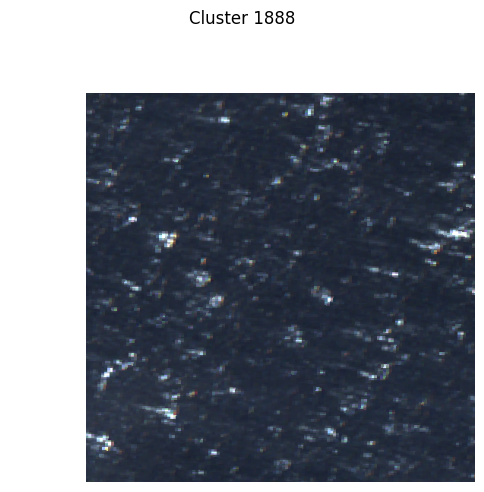

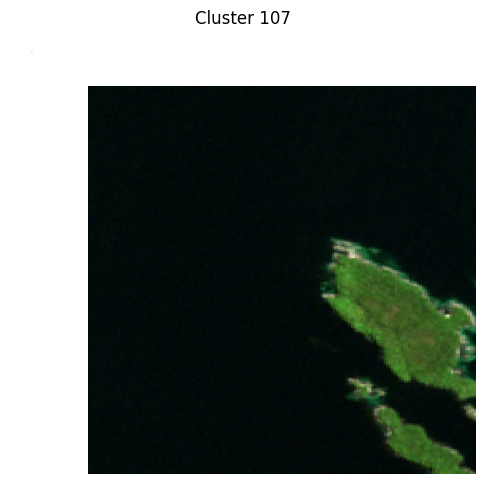

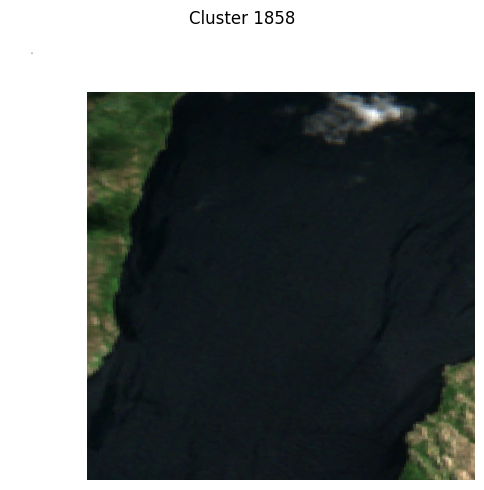

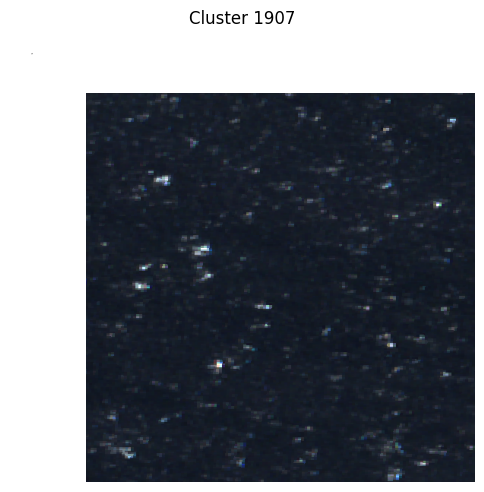

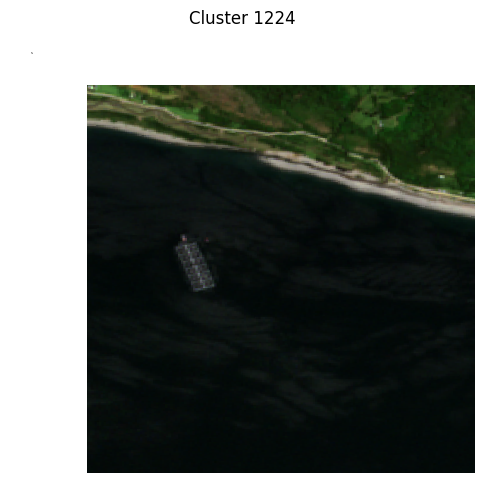

In [ ]:
import os
import numpy as np
import torch
import cv2
import geopandas as gpd
from shapely.geometry import Polygon
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import rasterio
from shapely.ops import transform as shapely_transform

download_folder

# ================== CONFIG ==================
OUTPUT_EPSG = 32718 # 32718=UTM  # 4326=lat/lon     # desired CRS for the shapefile
THRESH = 0.5
NUM_VISUAL_SAMPLES = 10  # how many example images to visualize
# ============================================

# ===== LOAD MODEL =====
model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# ===== TRANSFORM =====
transform = A.Compose([
    A.Normalize(mean=IMG_MEAN_3_CHANNEL, std=IMG_STD_3_CHANNEL),
    ToTensorV2()
])

# ===== LOAD CLUSTERS =====
clusters_df = pd.read_csv(CLUSTER_CSV)
if "cluster_id" not in clusters_df.columns:
    raise ValueError("clusters CSV must contain 'cluster_id' column.")

# ===== HELPERS =====
def mask_to_polygons(mask, min_area=MIN_AREA):
    """Convert binary mask to list of shapely Polygons (pixel coordinates)."""
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for c in contours:
        if cv2.contourArea(c) >= min_area:
            coords = c[:, 0, :]
            poly = Polygon([(float(x), float(y)) for x, y in coords])
            if poly.is_valid:
                polys.append(poly)
    return polys

def visualize_sample(image_array, polygons, title="Sample"):
    """Display image with polygons overlay."""
    img = image_array
    if img.ndim == 3 and img.shape[0] in [1,3]:
        img = img.transpose(1,2,0)
    img_disp = img.astype(np.float32)
    if img_disp.max() > 1:
        img_disp /= img_disp.max()

    plt.figure(figsize=(6,6))
    plt.imshow(img_disp)
    cmap = cm.get_cmap("tab10")
    for i, poly in enumerate(polygons):
        if poly.is_empty:
            continue
        try:
            x, y = poly.exterior.xy
            plt.fill(x, y, alpha=0.4, edgecolor='black', facecolor=cmap(i%10))
        except Exception:
            for geom in getattr(poly, "geoms", [poly]):
                x, y = geom.exterior.xy
                plt.fill(x, y, alpha=0.4, edgecolor='black', facecolor=cmap(i%10))
    plt.title(title)
    plt.axis("off")
    plt.show()


def pixel_to_coords(poly, affine_transform):
    """Convert polygon in pixel coords to geospatial coords using affine transform."""
    def _transform(x, y):
        lon, lat = rasterio.transform.xy(affine_transform, y, x)  # row=y, col=x
        return lon, lat
    return shapely_transform(_transform, poly)

# ===== INFERENCE =====
records = []

print("Starting inference...")
for idx, row in clusters_df.iterrows():
    cluster_id = int(row["cluster_id"])
    npy_path = os.path.join(IMAGE_DIR, f"sentinel2_{cluster_id}.npy")
    tif_path = os.path.join(download_folder, f"sentinel2_{cluster_id}.tiff")

    if not os.path.exists(npy_path):
        print(f"[WARN] Missing file: {npy_path}")
        continue

    if not os.path.exists(tif_path):
        print(f"[WARN] Missing GeoTIFF: {tif_path}")
        continue

    print(f"[INFO] Processing cluster {cluster_id} ({idx+1}/{len(clusters_df)})...")
    img = np.load(npy_path).astype(np.float32)
    if img.ndim == 3 and img.shape[0] in [1,3]:
        img = img.transpose(1,2,0)

    aug = transform(image=img)
    tensor = aug["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits)[0,0].cpu().numpy()
        mask = (probs > THRESH).astype(np.uint8) * 255

    polys = mask_to_polygons(mask)
    print(f"  Detected {len(polys)} polygon(s).")

    # =====map polygons to real coordinates =====
    with rasterio.open(tif_path) as src:
        affine_transform = src.transform
        crs = src.crs

        for poly in polys:
            geo_poly = pixel_to_coords(poly, affine_transform)
            records.append({
                "cluster_id": cluster_id,
                "geometry": geo_poly
            })

# ===== BUILD GDF =====
if not records:
    raise SystemExit("No polygons detected!")

# use the CRS from the GeoTIFFs
gdf = gpd.GeoDataFrame(records, crs=crs)

# reproject to force WGS84 (lat/lon)
gdf = gdf.to_crs(epsg=OUTPUT_EPSG)

# ===== SAVE SHAPEFILE =====
out_dir = os.path.dirname(OUTPUT_SHP)
if out_dir and not os.path.exists(out_dir):
    os.makedirs(out_dir, exist_ok=True)

gdf.to_file(OUTPUT_SHP)
print(f"Saved {len(gdf)} predicted cages to {OUTPUT_SHP} with CRS EPSG:{OUTPUT_EPSG}")

# ===== VISUALIZE SOME SAMPLES =====
samples = random.sample(list(clusters_df["cluster_id"]), min(NUM_VISUAL_SAMPLES, len(clusters_df)))
for cluster_id in samples:
    npy_path = os.path.join(IMAGE_DIR, f"sentinel2_{cluster_id}.npy")
    if os.path.exists(npy_path):
        img = np.load(npy_path).astype(np.float32)
        if img.ndim == 3 and img.shape[0] in [1,3]:
            img = img.transpose(1,2,0)
        cluster_polys = [r["geometry"] for r in records if r["cluster_id"]==cluster_id]
        if cluster_polys:
            visualize_sample(img, cluster_polys, title=f"Cluster {cluster_id}")

# Visualizing results

---


In [ ]:
import geopandas as gpd
import pandas as pd
import folium
from tqdm import tqdm
import math

# ===== CONFIG =====
REF_SHP = path_shp #shp file used as reference or base
PRED_SHP = OUTPUT_SHP # shp file generated by the model
OUTPUT_CSV = os.path.dirname(OUTPUT_SHP) + "/comparison_metrics.csv" #resulting file containing numeric analysis
OUTPUT_HTML = os.path.dirname(OUTPUT_SHP) + "/predicted_vs_reference_map.html" #resulting graphical visualization of analysis
TOLERANCE = 20  # in CRS units (e.g., meters if UTM / EPSG:32718), change to 0.00005 grades for (WGS84 / EPSG:4326)

# ===== LOAD SHAPEFILES =====
ref_gdf = gpd.read_file(REF_SHP)
pred_gdf = gpd.read_file(PRED_SHP)

if ref_gdf.crs is None:
    print("Reference shapefile has no CRS, assuming (EPSG:32718)")
    ref_gdf.set_crs("EPSG:32718", allow_override=True, inplace=True)

if ref_gdf.crs != pred_gdf.crs:
    pred_gdf = pred_gdf.to_crs(ref_gdf.crs)

# ===== HELPER FUNCTION WITH TOLERANCE =====
def is_inside_with_tolerance(pred_poly, ref_poly, tolerance=TOLERANCE):
    buffered_ref = ref_poly.buffer(tolerance)  # expand reference polygon
    return pred_poly.within(buffered_ref)

# ===== COMPARISON =====
results = []
total_preds = len(pred_gdf)
log_interval = max(1, math.ceil(total_preds / 10))  # log every 10%

print("[INFO] Comparing predicted cages with reference cages...")

for idx, pred_row in tqdm(pred_gdf.iterrows(), total=total_preds, desc="Processing predictions"):
    pred_poly = pred_row.geometry
    best_iou = 0
    inside = False
    bigger = False
    best_ref_area = None

    for _, ref_row in ref_gdf.iterrows():
        ref_poly = ref_row.geometry
        iou = pred_poly.intersection(ref_poly).area / pred_poly.union(ref_poly).area
        if iou > best_iou:
            best_iou = iou
            inside = is_inside_with_tolerance(pred_poly, ref_poly, tolerance=TOLERANCE)
            bigger = pred_poly.area > ref_poly.area
            best_ref_area = ref_poly.area

    centroid = pred_poly.centroid
    results.append({
        "cluster_id": pred_row.get("cluster_id", None),
        "pred_area": pred_poly.area,
        "ref_area": best_ref_area,
        "inside": inside,
        "bigger": bigger,
        "iou": best_iou,
        "centroid_lon": centroid.x,
        "centroid_lat": centroid.y
    })

    if (idx + 1) % log_interval == 0 or (idx + 1) == total_preds:
        print(f"[INFO] Processed {idx + 1}/{total_preds} predicted polygons "
              f"({((idx + 1)/total_preds)*100:.0f}%) - Best IoU for last polygon: {best_iou:.3f}")

# ===== SAVE CSV =====
df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT_CSV, index=False)
print(f"[INFO] Saved comparison metrics to {OUTPUT_CSV}")

# ===== INTERACTIVE MAP =====
print("[INFO] Creating interactive map...")
ref_map = ref_gdf.to_crs(epsg=4326)
pred_map = pred_gdf.to_crs(epsg=4326)
for i, r in enumerate(results):
    pred_map.at[i, 'inside'] = r['inside']

center = pred_map.unary_union.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=14, tiles="OpenStreetMap")

for _, row in ref_map.iterrows():
    geo_json = gpd.GeoSeries(row.geometry).simplify(0.0001).to_json()
    folium.GeoJson(
        geo_json,
        style_function=lambda x: {'color': 'blue', 'weight':2, 'fill': False},
        tooltip="Reference cage"
    ).add_to(m)

for _, row in pred_map.iterrows():
    geo_json = gpd.GeoSeries(row.geometry).simplify(0.0001).to_json()
    color = 'green' if row['inside'] else 'red'
    folium.GeoJson(
        geo_json,
        style_function=lambda x, color=color: {'color': color, 'weight':2, 'fill': True, 'fillOpacity':0.4},
        tooltip=f"Predicted cage - inside: {row['inside']}"
    ).add_to(m)

m.save(OUTPUT_HTML)
print(f"[INFO] Saved interactive map to {OUTPUT_HTML}")

Reference shapefile has no CRS, assuming (EPSG:32718)
[INFO] Comparing predicted cages with reference cages...


Processing predictions:  10%|█         | 111/1101 [00:55<07:44,  2.13it/s]

[INFO] Processed 111/1101 predicted polygons (10%) - Best IoU for last polygon: 0.207


Processing predictions:  20%|██        | 222/1101 [01:53<06:39,  2.20it/s]

[INFO] Processed 222/1101 predicted polygons (20%) - Best IoU for last polygon: 0.335


...

[INFO] Processed 999/1101 predicted polygons (91%) - Best IoU for last polygon: 0.517


Processing predictions: 100%|██████████| 1101/1101 [09:17<00:00,  1.98it/s]

[INFO] Processed 1101/1101 predicted polygons (100%) - Best IoU for last polygon: 0.004
[INFO] Saved comparison metrics to /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/result/comparison_metrics.csv
[INFO] Creating interactive map...



/tmp/ipython-input-2112821097.py:81: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = pred_map.unary_union.centroid


[INFO] Saved interactive map to /content/drive/MyDrive/RPTU/SM_25 25/AAI_Project/release/result/predicted_vs_reference_map.html
